In [1]:
import numpy as np
import pandas as pd

In [2]:
train_df= pd.read_csv('PubMed_20k_RCT/train.csv')
dev_df = pd.read_csv('PubMed_20k_RCT/dev.csv')
test_df = pd.read_csv('PubMed_20k_RCT/test.csv')
train_df.head()

,abstract_id,line_id,abstract_text,line_number,total_lines,target
0,24293578,24293578_0_12,To investigate the efficacy of 6 weeks of dail...,0,12,OBJECTIVE
1,24293578,24293578_1_12,A total of 125 patients with primary knee OA w...,1,12,METHODS
2,24293578,24293578_2_12,Outcome measures included pain reduction and i...,2,12,METHODS
3,24293578,24293578_3_12,Pain was assessed using the visual analog pain...,3,12,METHODS
4,24293578,24293578_4_12,Secondary outcome measures included the Wester...,4,12,METHODS


In [3]:
print(train_df.describe())
print(train_df.info())

        abstract_id    line_number    total_lines
count  1.800400e+05  180040.000000  180040.000000
mean   2.501496e+07       5.894568      12.789136
std    5.153296e+05       4.127672       3.236095
min    2.421977e+07       0.000000       4.000000
25%    2.458516e+07       3.000000      11.000000
50%    2.495697e+07       6.000000      12.000000
75%    2.539212e+07       9.000000      15.000000
max    2.652916e+07      30.000000      31.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180040 entries, 0 to 180039
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   abstract_id    180040 non-null  int64 
 1   line_id        180040 non-null  object
 2   abstract_text  180040 non-null  object
 3   line_number    180040 non-null  int64 
 4   total_lines    180040 non-null  int64 
 5   target         180040 non-null  object
dtypes: int64(3), object(3)
memory usage: 8.2+ MB
None


In [4]:
print(dev_df.describe())
print(dev_df.info())

        abstract_id   line_number   total_lines
count  3.021200e+04  30212.000000  30212.000000
mean   2.502800e+07      5.930988     12.861975
std    5.098474e+05      4.142448      3.220353
min    2.421989e+07      0.000000      4.000000
25%    2.460663e+07      3.000000     11.000000
50%    2.498672e+07      6.000000     12.000000
75%    2.540678e+07      9.000000     15.000000
max    2.652158e+07     26.000000     27.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30212 entries, 0 to 30211
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   abstract_id    30212 non-null  int64 
 1   line_id        30212 non-null  object
 2   abstract_text  30212 non-null  object
 3   line_number    30212 non-null  int64 
 4   total_lines    30212 non-null  int64 
 5   target         30212 non-null  object
dtypes: int64(3), object(3)
memory usage: 1.4+ MB
None


In [5]:
print(test_df.describe())
print(test_df.info())

        abstract_id   line_number   total_lines
count  3.013500e+04  30135.000000  30135.000000
mean   2.504292e+07      5.922980     12.845960
std    5.209988e+05      4.141561      3.232885
min    2.422001e+07      0.000000      4.000000
25%    2.461834e+07      3.000000     11.000000
50%    2.500021e+07      6.000000     12.000000
75%    2.542062e+07      9.000000     15.000000
max    2.652158e+07     27.000000     28.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30135 entries, 0 to 30134
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   abstract_id    30135 non-null  int64 
 1   line_id        30135 non-null  object
 2   abstract_text  30135 non-null  object
 3   line_number    30135 non-null  int64 
 4   total_lines    30135 non-null  int64 
 5   target         30135 non-null  object
dtypes: int64(3), object(3)
memory usage: 1.4+ MB
None


In [6]:
# # Drop the unneccassry column
train_df = train_df.drop(columns=['abstract_id', 'line_id'])
dev_df = dev_df.drop(columns=['abstract_id', 'line_id'])
# med_data_test = med_data_test.drop(columns=['abstract_id', 'line_id'])
dev_df.head()

,abstract_text,line_number,total_lines,target
0,IgE sensitization to Aspergillus fumigatus and...,0,10,BACKGROUND
1,It is not clear whether these patients would b...,1,10,BACKGROUND
2,We sought to determine whether a 3-month cours...,2,10,OBJECTIVE
3,Asthmatic patients who were IgE sensitized to ...,3,10,METHODS
4,Primary outcomes were improvement in quality o...,4,10,METHODS


In [7]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Shyam\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Shyam\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Shyam\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [9]:
X_train = train_df["abstract_text"].astype(str)
y_train = train_df["target"]

X_val = dev_df["abstract_text"].astype(str)
y_val = dev_df["target"]

X_test = test_df["abstract_text"].astype(str)
y_test = test_df["target"]

In [10]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    return text

In [11]:
X_train = X_train.apply(clean_text)
X_val   = X_val.apply(clean_text)
X_test  = X_test.apply(clean_text)

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=80000,
    stop_words="english",
    sublinear_tf=True
)

X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec   = vectorizer.transform(X_val)
X_test_vec  = vectorizer.transform(X_test)

In [32]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train_vec, y_train)

,alpha,0.1
,force_alpha,True
,fit_prior,True
,class_prior,None


In [33]:
from sklearn.metrics import accuracy_score

y_pred = nb_model.predict(X_test_vec)
accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.7422


In [34]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

  BACKGROUND       0.58      0.55      0.57      3621
 CONCLUSIONS       0.64      0.63      0.63      4571
     METHODS       0.80      0.87      0.83      9897
   OBJECTIVE       0.58      0.43      0.50      2333
     RESULTS       0.81      0.81      0.81      9713

    accuracy                           0.74     30135
   macro avg       0.68      0.66      0.67     30135
weighted avg       0.74      0.74      0.74     30135



In [35]:
from sklearn.metrics import confusion_matrix
import pandas as pd

cm = confusion_matrix(y_test, y_pred, labels=nb_model.classes_)
cm_df = pd.DataFrame(cm, index=nb_model.classes_, columns=nb_model.classes_)
print(cm_df)

             BACKGROUND  CONCLUSIONS  METHODS  OBJECTIVE  RESULTS
BACKGROUND         2006          653      360        469      133
CONCLUSIONS         485         2878      291        128      789
METHODS             193          195     8562        110      837
OBJECTIVE           642          300      312       1014       65
RESULTS             116          478     1179         35     7905


In [36]:
errors = test_df.copy()
errors["prediction"] = y_pred

misclassified = errors[errors["target"] != errors["prediction"]]
misclassified.head(10)

,abstract_id,line_id,abstract_text,line_number,total_lines,target,prediction
1,24845963,24845963_1_9,A post hoc analysis was conducted with the use...,1,9,RESULTS,METHODS
2,24845963,24845963_2_9,Liver function tests ( LFTs ) were measured at...,2,9,RESULTS,METHODS
8,24845963,24845963_8_9,Elevated MELD-XI scores are associated with po...,8,9,CONCLUSIONS,BACKGROUND
9,24469619,24469619_0_13,Minimally invasive endovascular aneurysm repai...,0,13,BACKGROUND,OBJECTIVE
10,24469619,24469619_1_13,The aim of this study was to analyse the cost-...,1,13,BACKGROUND,OBJECTIVE
14,24469619,24469619_5_13,A total of 116 patients were randomized .,5,13,RESULTS,METHODS
20,24469619,24469619_11_13,Nor was EVAR superior regarding cost-utility .,11,13,RESULTS,CONCLUSIONS
23,25552432,25552432_1_9,This study investigated whether oxytocin can a...,1,9,METHODS,BACKGROUND
27,25552432,25552432_5_9,Oxytocin reduced the difference between HSA an...,5,9,RESULTS,CONCLUSIONS
28,25552432,25552432_6_9,"Moreover , it appeared to normalize attentiona...",6,9,RESULTS,CONCLUSIONS


In [39]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    ngram_range=(1, 2),
    max_features=60000,
    min_df=2
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec  = vectorizer.transform(X_test)

In [40]:
from sklearn.naive_bayes import ComplementNB
model = ComplementNB(alpha=0.5)
model.fit(X_train_vec, y_train)

,alpha,0.5
,force_alpha,True
,fit_prior,True
,class_prior,None
,norm,False


In [41]:
print("a " + "  Accuracy_Score")
for a in [0.01, 0.05, 0.1, 0.5, 1.0]:
    model = ComplementNB(alpha=a)
    model.fit(X_train_vec, y_train)
    preds = model.predict(X_test_vec)
    print(a, accuracy_score(y_test, preds))

a   Accuracy_Score
0.01 0.7821801891488303
0.05 0.7823792931806869
0.1 0.7824788451966153
0.5 0.7827111332337813
1.0 0.7825452132072341


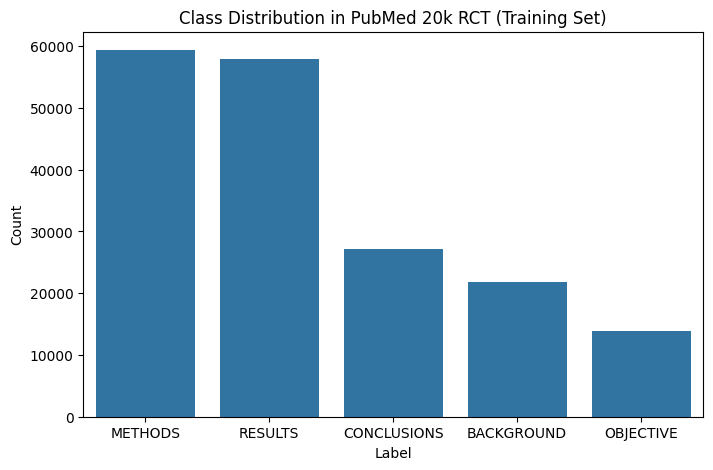

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(x=y_train, order=y_train.value_counts().index)
plt.title("Class Distribution in PubMed 20k RCT (Training Set)")
plt.ylabel("Count")
plt.xlabel("Label")
plt.show()

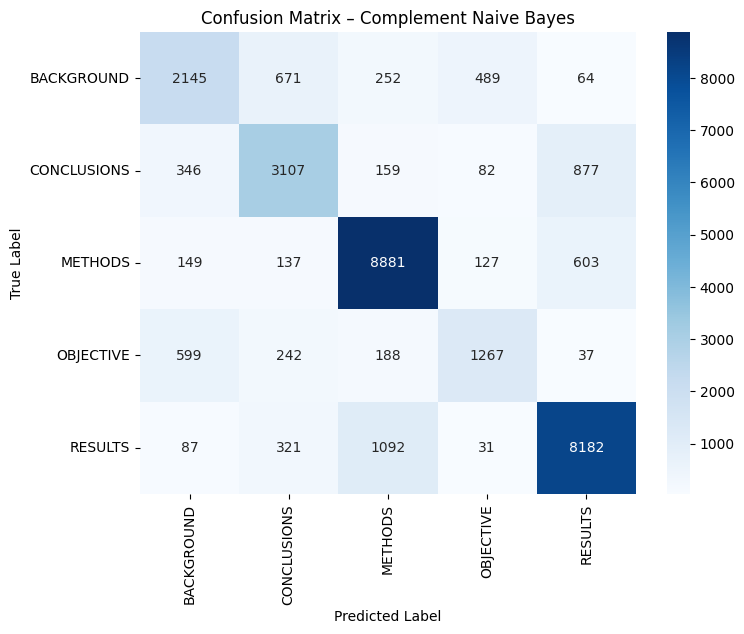

In [44]:
from sklearn.metrics import confusion_matrix
import pandas as pd

cm = confusion_matrix(y_test, preds, labels=model.classes_)
cm_df = pd.DataFrame(cm, index=model.classes_, columns=model.classes_)

plt.figure(figsize=(8,6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix – Complement Naive Bayes")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

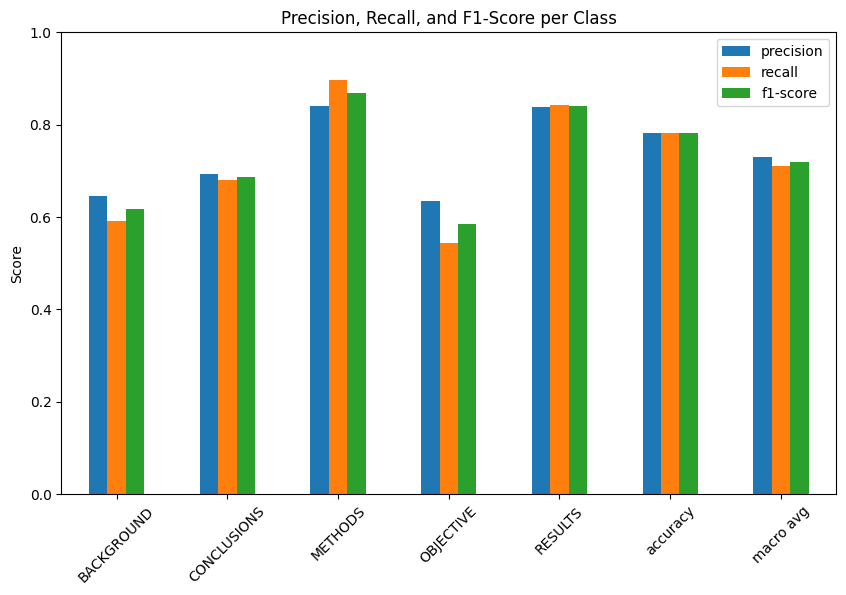

In [46]:
from sklearn.metrics import classification_report

report = classification_report(y_test, preds, output_dict=True)
report_df = pd.DataFrame(report).transpose()

report_df.iloc[:-1, :3].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Precision, Recall, and F1-Score per Class")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.ylim(0,1)
plt.show()


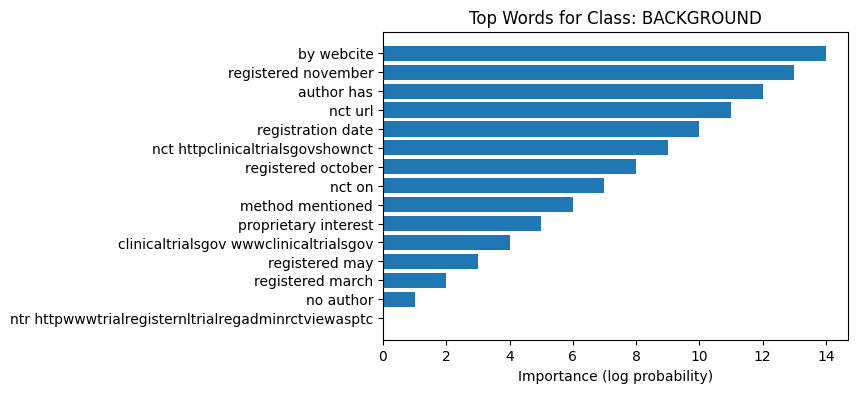

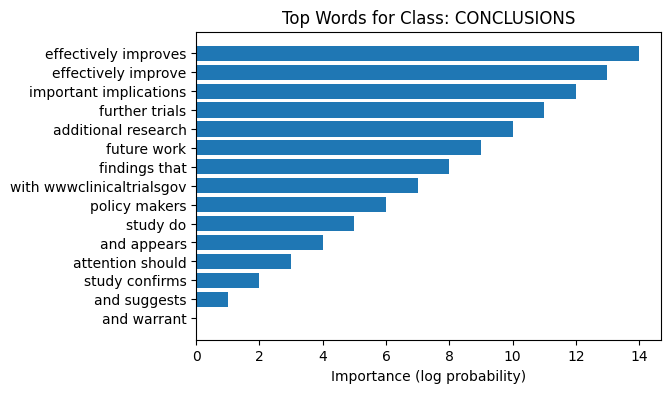

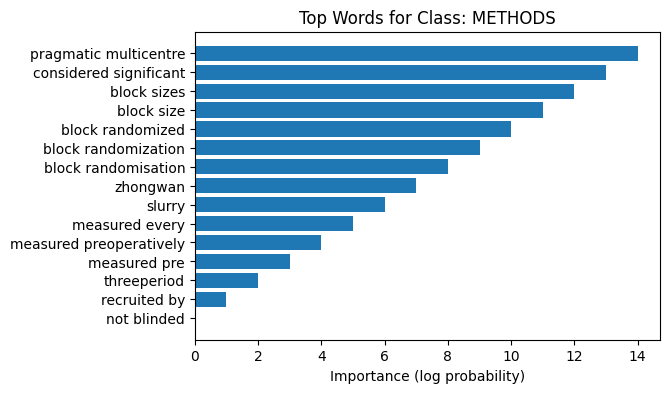

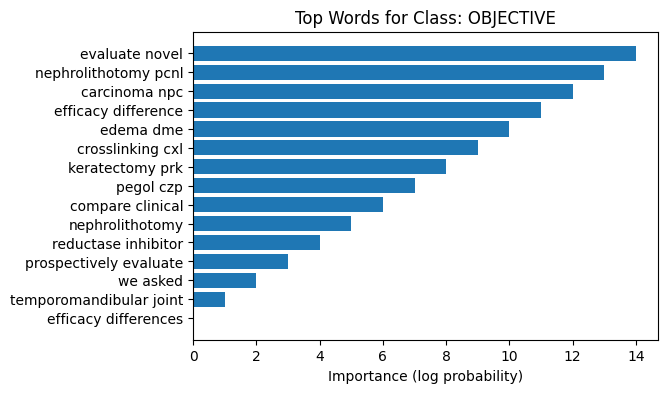

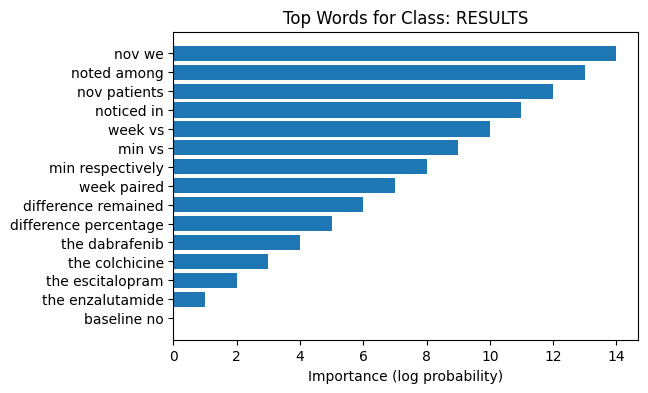

In [47]:
import numpy as np

feature_names = np.array(vectorizer.get_feature_names_out())

for i, label in enumerate(model.classes_):
    top_words = feature_names[
        np.argsort(model.feature_log_prob_[i])[-15:]
    ]
    
    plt.figure(figsize=(6,4))
    plt.barh(top_words, range(len(top_words)))
    plt.title(f"Top Words for Class: {label}")
    plt.xlabel("Importance (log probability)")
    plt.show()